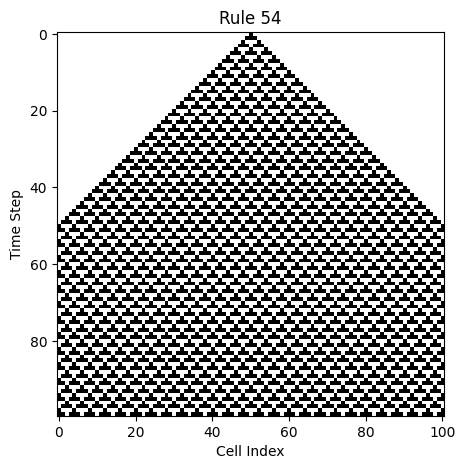

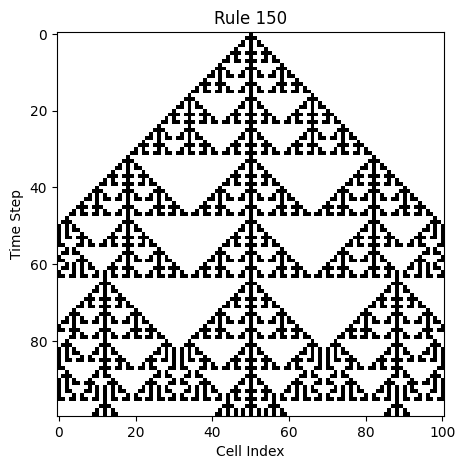

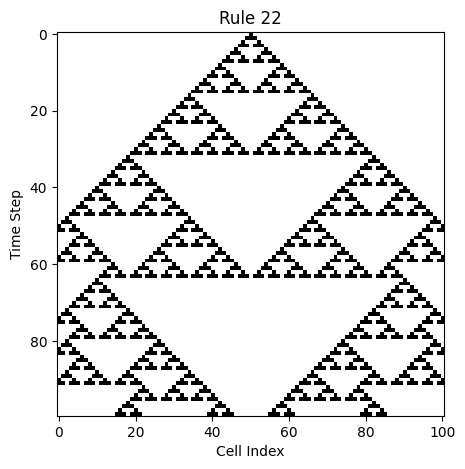

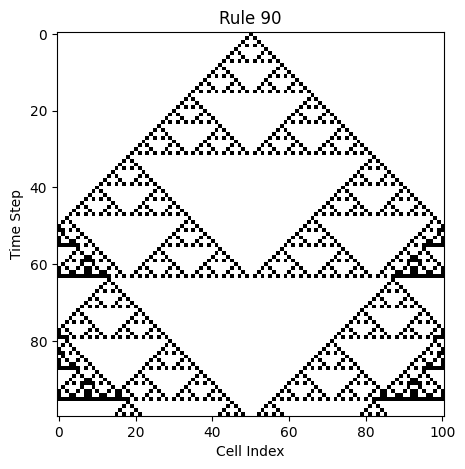

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Функции для вычислений

def rule_to_dict(rule_number: int) -> dict:
    """
    Преобразует номер правила (0–255) в отображение из 3-битового окрестности
    в новое состояние клетки (0 или 1).
    """
    bin_str = f"{rule_number:08b}"
    neighborhoods = [
        (1,1,1), (1,1,0), (1,0,1), (1,0,0),
        (0,1,1), (0,1,0), (0,0,1), (0,0,0),
    ]
    return {nb: int(bit) for nb, bit in zip(neighborhoods, bin_str)}

def run_1d_ca(initial, rule_dict, steps, boundary='fixed'):
    """
    Запускает одномерный клеточный автомат:
    initial — начальный вектор (массив нулей и единиц),
    rule_dict — отображение окрестности -> новое состояние,
    steps — число шагов эволюции.
    Возвращает матрицу history размером (steps × width).
    """
    width = initial.size
    history = np.zeros((steps, width), dtype=int)
    history[0] = initial
    for t in range(1, steps):
        prev = history[t-1]
        new = np.zeros_like(prev)
        for i in range(width):
            if boundary == 'wrap':
                left  = prev[(i-1) % width]
                right = prev[(i+1) % width]
            else:
                left  = prev[i-1] if i-1 >= 0    else 0
                right = prev[i+1] if i+1 < width else 0
            center = prev[i]
            new[i] = rule_dict[(left, center, right)]
        history[t] = new
    return history

def plot_ca(history: np.ndarray, title: str = None):
    """
    Строит эволюцию CA: по вертикали — время, по горизонтали — индекс клетки.
    """
    plt.figure(figsize=(5, 5))
    plt.imshow(history, cmap='binary', interpolation='nearest')
    plt.xlabel('Cell Index')
    plt.ylabel('Time Step')
    if title:
        plt.title(title)
    plt.show()


# Параметры симуляции
width = 101        # число клеток в ряду
steps = 100        # число шагов эволюции
rules = [54, 150, 22]
  # список правил, которые хотим прогнать

initial = np.zeros(width, dtype=int)
initial[width // 2] = 1

# Основной цикл по правилам
for rule_number in rules:
    rule_map = rule_to_dict(rule_number)
    bmode = 'wrap' if rule_number in (30, 90) else 'fixed'
    history = run_1d_ca(initial, rule_map, steps, boundary=bmode)
    plot_ca(history, title=f'Rule {rule_number}')
